# Extended Data Fig. 5

Coverage and regional agreement between ONT and PacBio.

In [1]:
import sys; sys.path.insert(0, "../scripts"); sys.path.insert(0, "../scripts/paper")
from pathlib import Path
from nbkit import setup, paper_py, paper_r, run_r_source, harvest, show, have_r_package, DATA

OUT = setup("../figures/notebook")
print("panels will be written to", OUT)

# %%R cells below run R natively in this kernel through rpy2, so the R panels are R code
# in the notebook rather than a string that gets written to a file.
%load_ext rpy2.ipython

panels will be written to ./figures/notebook


## a - CpG sites covered at five or more reads by each platform

wrote ./figures/notebook/venn_cov5_nm.pdf/.png  ONT 63,130,991 PacBio 63,617,062 both 62,100,976  7.0 pt


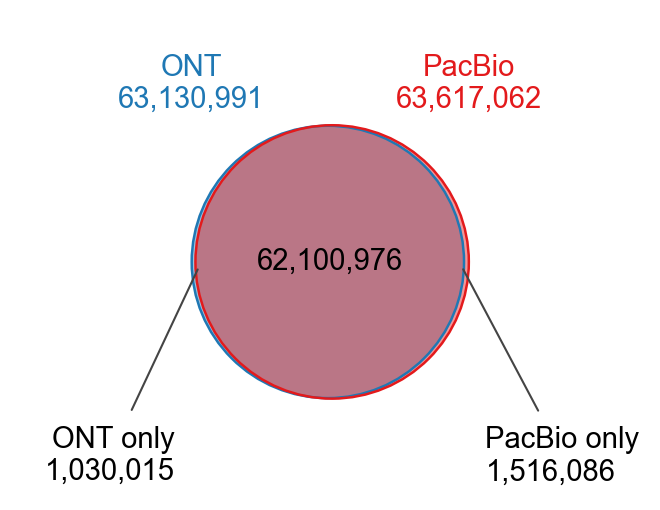

In [2]:
# scripts/paper/venn_nm.py, inlined. sys.argv is what the paper passes it.
import sys
sys.argv = ['venn_nm.py', f'{DATA}/ed_fig5/A_venn_covered_cpg_cov5_stats.tsv', f'{OUT}/venn_cov5_nm']
__file__ = "../scripts/paper/venn_nm.py"

"""Two-set Venn of CpG sites covered at five or more reads, ONT and PacBio, from the counts in
the stats table (plot_perSite_venn.R wrote it). 7 pt, 2.2 x 1.7 in. Circle areas are
proportional to the set sizes and the overlap is placed by the overlap count, so the picture
is read off the same five numbers it prints.

Usage: 11_venn_nm.py <venn_stats.tsv> <out_stem>          (env: conda/envs/py39_v2)
"""
from __future__ import annotations

import math
import os
import sys

import matplotlib
matplotlib.use("Agg")
import matplotlib.font_manager
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from scipy.optimize import brentq

PT = float(os.environ.get("PANEL_MIN_PT", 7))
FD = os.environ.get("LONGVERSE_FONT_DIR", "/project2/sli68423_1316/users/yang/software/fonts")
fam = "DejaVu Sans"
for t in ("arial.ttf", "arialbd.ttf"):
    if os.path.isfile(os.path.join(FD, t)):
        matplotlib.font_manager.fontManager.addfont(os.path.join(FD, t))
if os.path.isfile(os.path.join(FD, "arial.ttf")):
    fam = "Arial"
plt.rcParams.update({"font.family": fam, "font.size": PT, "pdf.fonttype": 42, "ps.fonttype": 42})
ONT_C, PB_C = "#1f78b4", "#e31a1c"


def lens_area(d, r1, r2):
    if d >= r1 + r2:
        return 0.0
    if d <= abs(r1 - r2):
        return math.pi * min(r1, r2) ** 2
    a1 = r1 * r1 * math.acos((d * d + r1 * r1 - r2 * r2) / (2 * d * r1))
    a2 = r2 * r2 * math.acos((d * d + r2 * r2 - r1 * r1) / (2 * d * r2))
    return a1 + a2 - 0.5 * math.sqrt((-d + r1 + r2) * (d + r1 - r2) * (d - r1 + r2) * (d + r1 + r2))


def main() -> int:
    stats, stem = sys.argv[1], sys.argv[2]
    kv = dict(l.rstrip("\n").split("\t") for l in open(stats) if "\t" in l and not l.startswith("metric"))
    tot1, tot2, both = int(kv["ONT_total"]), int(kv["PacBio_total"]), int(kv["overlap"])
    only1, only2 = int(kv["ONT_only"]), int(kv["PacBio_only"])
    assert tot1 == both + only1 and tot2 == both + only2, "the five counts do not add up"
    r1, r2 = math.sqrt(tot1 / math.pi), math.sqrt(tot2 / math.pi)
    d = brentq(lambda x: lens_area(x, r1, r2) - both, abs(r1 - r2) + 1e-9, r1 + r2 - 1e-9)
    scale = 1.0 / (r1 + r2 + d)
    r1, r2, d = r1 * scale, r2 * scale, d * scale
    fig, ax = plt.subplots(figsize=(2.2, 1.7), constrained_layout=True)
    c1, c2 = (-d / 2, 0), (d / 2, 0)
    ax.add_patch(Circle(c1, r1, fc=ONT_C, ec="none", alpha=0.45))
    ax.add_patch(Circle(c2, r2, fc=PB_C, ec="none", alpha=0.45))
    ax.add_patch(Circle(c1, r1, fc="none", ec=ONT_C, lw=0.6))
    ax.add_patch(Circle(c2, r2, fc="none", ec=PB_C, lw=0.6))
    # labels: the two crescents hold almost nothing, so their counts sit outside with a leader
    ax.text(0, 0, f"{both:,}", ha="center", va="center", fontsize=PT)
    # the sets overlap by 98%, so the two circles nearly coincide: the set labels go to the
    # upper left and upper right, clear of each other, rather than over each circle's centre
    top = max(r1, r2) + 0.04
    ax.text(-0.50, top, f"ONT\n{tot1:,}", ha="center", va="bottom", fontsize=PT, color=ONT_C)
    ax.text(0.50, top, f"PacBio\n{tot2:,}", ha="center", va="bottom", fontsize=PT, color=PB_C)
    ax.annotate(f"ONT only\n{only1:,}", xy=(c1[0] - r1 * 0.93, 0), xytext=(c1[0] - r1 - 0.06, -r1 - 0.10),
                ha="right", va="top", fontsize=PT, arrowprops=dict(arrowstyle="-", lw=0.5, color="#444444"))
    ax.annotate(f"PacBio only\n{only2:,}", xy=(c2[0] + r2 * 0.93, 0), xytext=(c2[0] + r2 + 0.06, -r2 - 0.10),
                ha="left", va="top", fontsize=PT, arrowprops=dict(arrowstyle="-", lw=0.5, color="#444444"))
    ax.set_xlim(-0.98, 0.98); ax.set_ylim(-0.85, 0.90); ax.set_aspect("equal"); ax.axis("off")
    fig.savefig(stem + ".pdf"); fig.savefig(stem + ".png", dpi=300)
    print(f"wrote {stem}.pdf/.png  ONT {tot1:,} PacBio {tot2:,} both {both:,}  {PT} pt")
    return 0

main()
show("venn_cov5_nm.png")

## b - per-site coverage distributions

Drawn over the whole distribution with the coverage-5 threshold marked. Truncating there would hide the left tail the panel is about.

platform	sites	mean_cov	median_cov	sites_cov_ge5	pct_cov_ge5
ONT	65801544	29.45	30	63130991	95.94
PacBio	65314640	26.16	26	63617062	97.40
wrote ./figures/notebook/coverage_hist_nm.pdf/.png  7.0 pt


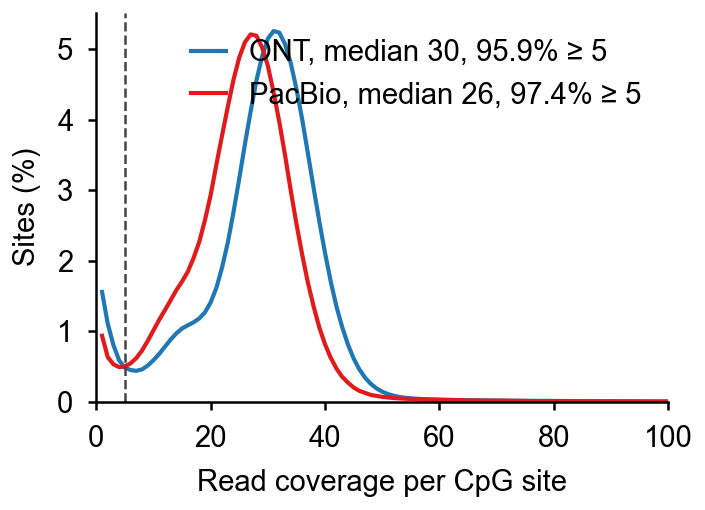

In [3]:
# scripts/paper/coverage_hist_nm.py, inlined. sys.argv is what the paper passes it.
import sys
sys.argv = ['coverage_hist_nm.py', f'{DATA}/ed_fig5', f'{OUT}/coverage_hist_nm']
__file__ = "../scripts/paper/coverage_hist_nm.py"

"""Per-site coverage distributions, ONT and PacBio, from the per-coverage site counts that
suppfig2/41_coverage_histogram.sbatch wrote (one row per integer coverage). 7 pt, 2.35 x 1.7 in.
The medians and the share of sites at coverage five or more are computed here from the same
counts and written next to the panel.

Usage: 12_coverage_hist_nm.py <source_data dir> <out_stem>          (env: conda/envs/py39_v2)
"""
from __future__ import annotations

import os
import sys

import matplotlib
matplotlib.use("Agg")
import matplotlib.font_manager
import matplotlib.pyplot as plt
import numpy as np

PT = float(os.environ.get("PANEL_MIN_PT", 7))
FD = os.environ.get("LONGVERSE_FONT_DIR", "/project2/sli68423_1316/users/yang/software/fonts")
fam = "DejaVu Sans"
for t in ("arial.ttf", "arialbd.ttf"):
    if os.path.isfile(os.path.join(FD, t)):
        matplotlib.font_manager.fontManager.addfont(os.path.join(FD, t))
if os.path.isfile(os.path.join(FD, "arial.ttf")):
    fam = "Arial"
plt.rcParams.update({"font.family": fam, "font.size": PT, "axes.labelsize": PT, "xtick.labelsize": PT,
                     "ytick.labelsize": PT, "legend.fontsize": PT, "pdf.fonttype": 42, "ps.fonttype": 42,
                     "axes.spines.top": False, "axes.spines.right": False, "axes.linewidth": 0.6,
                     "xtick.major.width": 0.6, "ytick.major.width": 0.6, "xtick.major.size": 2, "ytick.major.size": 2})


def load(p):
    a = np.loadtxt(p, dtype="int64", ndmin=2)
    return a[:, 0], a[:, 1]


def stats(x, y):
    n = y.sum(); cs = np.cumsum(y)
    return n, (x * y).sum() / n, x[np.searchsorted(cs, n / 2)], y[x >= 5].sum()


def main() -> int:
    src, stem = sys.argv[1], sys.argv[2]
    XMAX = 100
    fig, ax = plt.subplots(figsize=(2.35, 1.7), constrained_layout=True)
    lines = ["platform\tsites\tmean_cov\tmedian_cov\tsites_cov_ge5\tpct_cov_ge5"]
    for lab, fn, col in (("ONT", "B_coverage_hist_ont.tsv", "#1f78b4"), ("PacBio", "B_coverage_hist_pacbio.tsv", "#e31a1c")):
        x, y = load(os.path.join(src, fn))
        n, mean, med, ge5 = stats(x, y)
        m = x <= XMAX
        ax.plot(x[m], y[m] / n * 100.0, lw=1.0, color=col, label=f"{lab}, median {med}, {ge5 / n * 100:.1f}% ≥ 5")
        lines.append(f"{lab}\t{n}\t{mean:.2f}\t{med}\t{ge5}\t{ge5 / n * 100:.2f}")
    ax.axvline(5, color="#444444", lw=0.6, ls="--")
    ax.set_xlim(0, XMAX); ax.set_ylim(bottom=0)
    ax.set_xlabel("Read coverage per CpG site"); ax.set_ylabel("Sites (%)")
    ax.legend(frameon=False, loc="upper right", handlelength=1.2)
    fig.savefig(stem + ".pdf"); fig.savefig(stem + ".png", dpi=300)
    open(stem + "_stats.tsv", "w").write("\n".join(lines) + "\n")
    print("\n".join(lines)); print(f"wrote {stem}.pdf/.png  {PT} pt")
    return 0

main()
show("coverage_hist_nm.png")

## c - haplotype difference by region set, with paired Wilcoxon tests

In [4]:
%%R
## scripts/paper/boxplot_nm.R, run as R. Edit any line and re-run the cell.
Sys.setenv(ICR_BASE_PT = "7")

#!/usr/bin/env Rscript
## Absolute haplotype methylation difference at the imprinting control regions covered by both
## platforms, by region set, ONT against PacBio, with the paired Wilcoxon test per set.
## 7 pt, 2.4 x 1.7 in. Parameterised copy of results/2026_10_03_2platform_phasing_jasmine/
## _compare_ont_pacbio_boxplot_for_region.R; the region counts and tests are recomputed and
## written next to the panel, and checked against that script's txt.
##
## Usage: 14_boxplot_nm.R <merged annotation csv> <outdir>      Env: ICR_BASE_PT (7)
suppressPackageStartupMessages({ library(tidyverse); library(ggpubr) })
## commandArgs replaced for the notebook; everything else is the paper's file
argv <- c(file.path(Sys.getenv("LV_DATA"), "ed_fig4/hg002_ONT_Pacbio_merged_with_annotation.mincov5.inner.csv"), Sys.getenv("LV_OUT")); stopifnot(length(argv) == 2)
input <- argv[1]; outdir <- argv[2]; dir.create(outdir, showWarnings = FALSE, recursive = TRUE)
PT <- as.numeric(Sys.getenv("ICR_BASE_PT", "7"))

df2 <- read_csv(input, show_col_types = FALSE) %>%
    mutate(Region = case_when(Status == "Known" ~ "Known",
                              Status == "Novel" & Study == "Court-etal" ~ "Novel Court",
                              Status == "Novel" & Study == "Joshi-etal" ~ "Novel Joshi",
                              TRUE ~ "Other"),
           Region = factor(Region, levels = c("Known", "Novel Court", "Novel Joshi")))
stopifnot(!any(is.na(df2$Region)))
df_long <- df2 %>% select(Name, Region, ONT_HP_diff, Pacbio_HP_diff) %>%
    pivot_longer(c(ONT_HP_diff, Pacbio_HP_diff), names_to = "Platform", values_to = "HP_diff") %>%
    mutate(Platform = recode(Platform, ONT_HP_diff = "ONT", Pacbio_HP_diff = "PacBio"))

wilcox_df <- df2 %>% group_by(Region) %>%
    summarise(n = n(),
              statistic = wilcox.test(ONT_HP_diff, Pacbio_HP_diff, paired = TRUE)$statistic,
              p_value = wilcox.test(ONT_HP_diff, Pacbio_HP_diff, paired = TRUE)$p.value,
              median_ONT = median(ONT_HP_diff, na.rm = TRUE), median_PacBio = median(Pacbio_HP_diff, na.rm = TRUE),
              n_pairs_tested = sum(!is.na(ONT_HP_diff) & !is.na(Pacbio_HP_diff)), .groups = "drop")
write_tsv(wilcox_df, file.path(outdir, "hp_diff_by_region_nm_wilcoxon.tsv"))
print(wilcox_df)

labels <- wilcox_df %>% mutate(lab = sprintf("n = %d\nP = %s", n, formatC(p_value, digits = 2, format = "g")))
p <- ggplot(df_long, aes(x = Platform, y = HP_diff, fill = Platform)) +
    geom_boxplot(width = 0.6, outlier.size = 0.4, outlier.stroke = 0, alpha = 0.85, color = "grey25", lwd = 0.3) +
    scale_fill_manual(values = c("ONT" = "#1f78b4", "PacBio" = "#e31a1c")) +
    geom_text(data = labels, aes(x = 1.5, y = 1.04, label = lab), inherit.aes = FALSE, size = PT / ggplot2::.pt, vjust = 0, lineheight = 0.9) +
    facet_wrap(~Region, nrow = 1) +
    scale_y_continuous(breaks = seq(0, 1, 0.25)) +
    coord_cartesian(ylim = c(0, 1.22), clip = "off") +
    labs(x = NULL, y = "|HP1 - HP2| methylation") +
    theme_classic(base_size = PT) +
    theme(legend.position = "none",
          axis.text = element_text(color = "black", size = PT), axis.title = element_text(size = PT),
          strip.background = element_blank(), strip.text = element_text(size = PT),
          axis.line = element_line(linewidth = 0.3), axis.ticks = element_line(linewidth = 0.3),
          plot.margin = margin(t = 2, r = 2, b = 2, l = 2))
stem <- file.path(outdir, "hp_diff_by_region_nm")
ggsave(paste0(stem, ".pdf"), p, width = 2.4, height = 1.7, device = cairo_pdf)
ggsave(paste0(stem, ".png"), p, width = 2.4, height = 1.7, dpi = 300, type = "cairo")
cat("wrote", stem, ".pdf/.png\n")

Failed to query server: Transport endpoint is not connected


# A tibble: 3 × 7


  Region          n statistic    p_value median_ONT median_PacBio n_pairs_tested


  <fct>       <int>     <dbl>      <dbl>      <dbl>         <dbl>          <int>


1 Known          43       697    1.08e-7      0.712         0.600             38


...

3 Novel Joshi    33       366    5.70e-2      0.164         0.121             32


wrote

./figures/notebook/hp_diff_by_region_nm

.pdf/.png


In addition: Warning messages:
1: In system("timedatectl", intern = TRUE) :
  running command 'timedatectl' had status 1
2: Removed 13 rows containing non-finite outside the scale range
(`stat_boxplot()`). 
3: Using ragg device as default. Ignoring `type` and `antialias` arguments 
4: Removed 13 rows containing non-finite outside the scale range
(`stat_boxplot()`). 


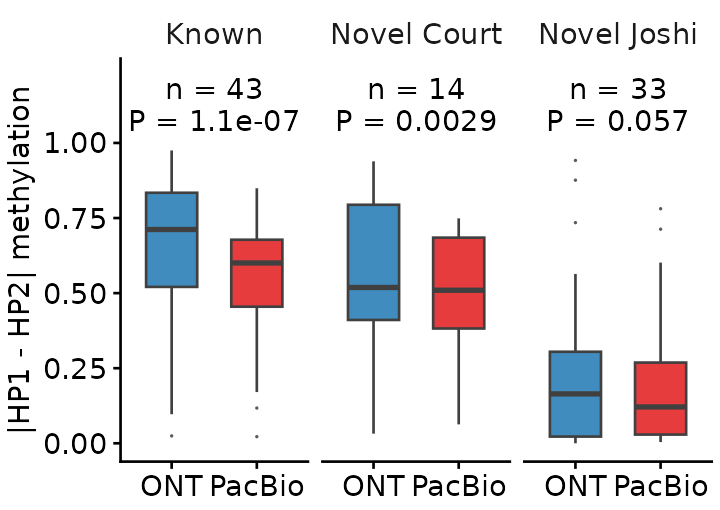

In [5]:
show('hp_diff_by_region_nm.png')

## d, e - imprinting control regions, HP1 minus HP2

ComplexHeatmap, novel regions in d and known ones in e. The script checks its own output row by row against a reference table before it writes, so a silent change in the numbers stops it rather than producing a plausible figure. The input lives under `data/ed_fig4/` because these two panels were f and g of Extended Data Fig. 4 until 2026-10-03; the paper's own build reads them from that directory too.

In [6]:
%%R
## scripts/paper/icr_heatmap_nm.R, run as R. Edit any line and re-run the cell.
Sys.setenv(ICR_BASE_PT = "7")

#!/usr/bin/env Rscript
## Imprinting-control-region heatmaps (HP1 minus HP2 methylation, ONT and PacBio) at Nature
## Methods size: 7 pt text, cells sized so the 43-column novel heatmap spans the 183 mm page.
##
## Parameterised copy of results/2026_10_03_2platform_phasing_jasmine/
## _2025_06_17_figure5_ab_plot_heatmap_compare_icr.R (the 12 pt deck version). Same input,
## same ordering (ONT difference descending), same colour scale; the plot tables it writes
## are checked row for row against that script's plotdf.csv, so the two renders cannot
## drift apart in content.
##
## Usage: 12_icr_heatmap_nm.R <input merged csv> <reference dir with *.plotdf.csv> <outdir>
## Env:   ICR_BASE_PT (7), ICR_CELL_W_MM (3.3), ICR_CELL_H_MM (4), ICR_COL_LABEL_MM (22)
suppressPackageStartupMessages({
    library(tidyverse); library(ComplexHeatmap); library(circlize); library(RColorBrewer); library(grid)
})
## commandArgs replaced for the notebook; everything else is the paper's file
argv <- c(file.path(Sys.getenv("LV_DATA"), "ed_fig4/hg002_ONT_Pacbio_merged_with_annotation.mincov5.inner.csv"), file.path(Sys.getenv("LV_DATA"), "ed_fig4"), Sys.getenv("LV_OUT"))
stopifnot(length(argv) == 3)
input_file <- argv[1]; ref_dir <- argv[2]; outdir <- argv[3]
dir.create(outdir, showWarnings = FALSE, recursive = TRUE)

BASE_PT <- as.numeric(Sys.getenv("ICR_BASE_PT", "7"))
CELL_W_MM <- as.numeric(Sys.getenv("ICR_CELL_W_MM", "3.3"))
CELL_H_MM <- as.numeric(Sys.getenv("ICR_CELL_H_MM", "4"))
ROW_GAP_MM <- 1
LEGEND_W_MM <- 16
ROW_LABEL_W_MM <- 11
## Room for the rotated gene names and for the legend title above the two rows. Both are tight
## rather than generous because these two panels moved into Extended Data Fig. 5 on 2026-10-03
## and that page has 247 mm for eight panels. A clipped label shows up in the PNG, so these are
## checked by eye after a change rather than assumed.
COL_LABEL_H_MM <- as.numeric(Sys.getenv("ICR_COL_LABEL_MM", "20"))
MARGIN_MM <- 2

df_all <- read_csv(input_file, show_col_types = FALSE) %>%
    transmute(Name = as.character(Name), Status = as.character(Status),
              ONT_diff = as.numeric(ONT_HP_diff), Pacbio_diff = as.numeric(Pacbio_HP_diff)) %>%
    drop_na(ONT_diff, Pacbio_diff) %>%
    arrange(desc(ONT_diff), desc(Pacbio_diff))
cat("rows:", nrow(df_all), " known:", sum(df_all$Status == "Known"), " novel:", sum(df_all$Status == "Novel"), "\n")

breaks <- seq(0, 1, length.out = 11)
col_fun <- colorRamp2(breaks, colorRampPalette(rev(brewer.pal(n = 7, name = "RdYlBu")))(length(breaks)))

plotdf_known <- df_all %>% filter(Status == "Known") %>% select(Name, ONT = ONT_diff, PacBio = Pacbio_diff)
plotdf_novel <- df_all %>% filter(Status == "Novel") %>% select(Name, ONT = ONT_diff, PacBio = Pacbio_diff) %>%
    mutate(Name = str_replace(Name, "intragenic_", "intra_"),
           Name = str_replace(Name, "PWARSN,SNORD107,PWARSN,PWAR5", "PWARSN,SNORD107"))

check_against_reference <- function(plotdf, ref_csv) {
    ref <- read_csv(ref_csv, show_col_types = FALSE)
    stopifnot(nrow(ref) == nrow(plotdf), all(ref$Name == plotdf$Name),
              max(abs(ref$ONT - plotdf$ONT)) < 1e-9, max(abs(ref$PacBio - plotdf$PacBio)) < 1e-9)
    cat("  matches", basename(ref_csv), "(", nrow(ref), "regions )\n")
}
check_against_reference(plotdf_known, file.path(ref_dir, "hg002_known_icr_hp_diff_heatmap.mincov5.plotdf.csv"))
check_against_reference(plotdf_novel, file.path(ref_dir, "hg002_novel_icr_hp_diff_heatmap.mincov5.plotdf.csv"))

draw_one <- function(plotdf, tag) {
    write_csv(plotdf, file.path(outdir, sprintf("icr_heatmap_%s_nm.plotdf.csv", tag)))
    mat <- plotdf %>% column_to_rownames("Name") %>% as.matrix() %>% t()
    n_col <- ncol(mat); n_row <- nrow(mat)
    italic_labels <- parse(text = paste0("italic('", plotdf$Name, "')"))
    ht <- Heatmap(mat, name = "HP1 - HP2", col = col_fun, na_col = "black",
                  width = unit(n_col * CELL_W_MM, "mm"),
                  height = unit(n_row * CELL_H_MM + (n_row - 1L) * ROW_GAP_MM, "mm"),
                  column_labels = italic_labels, column_title = character(0),
                  cluster_columns = FALSE, cluster_rows = FALSE, row_title = NULL,
                  column_names_gp = gpar(fontsize = BASE_PT), row_names_gp = gpar(fontsize = BASE_PT),
                  heatmap_legend_param = list(title_gp = gpar(fontsize = BASE_PT, fontface = "bold"),
                                              labels_gp = gpar(fontsize = BASE_PT),
                                              grid_width = unit(3, "mm"), legend_height = unit(14, "mm")),
                  row_split = factor(c("ONT", "PacBio"), levels = c("ONT", "PacBio")),
                  row_gap = unit(ROW_GAP_MM, "mm"), rect_gp = gpar(col = "#DDDDDD", lwd = 0.5))
    w_in <- (n_col * CELL_W_MM + LEGEND_W_MM + ROW_LABEL_W_MM + 2 * MARGIN_MM) / 25.4
    ## the legend is centred on the two heatmap rows and its title rises above them: 6 mm of
    ## headroom, or the title is clipped at the top of the device (seen 2026-10-03)
    TOP_MM <- MARGIN_MM + as.numeric(Sys.getenv("ICR_TOP_EXTRA_MM", "4"))
    h_in <- (n_row * CELL_H_MM + (n_row - 1L) * ROW_GAP_MM + COL_LABEL_H_MM + MARGIN_MM + TOP_MM) / 25.4
    stem <- file.path(outdir, sprintf("icr_heatmap_%s_nm", tag))
    pad <- unit(c(MARGIN_MM, MARGIN_MM, TOP_MM, MARGIN_MM), "mm")   # bottom, left, top, right
    cairo_pdf(paste0(stem, ".pdf"), width = w_in, height = h_in); draw(ht, padding = pad); dev.off()
    png(paste0(stem, ".png"), width = w_in, height = h_in, units = "in", res = 300, type = "cairo")
    draw(ht, padding = pad); dev.off()
    cat(sprintf("wrote %s.pdf/.png  %d regions, %.2f x %.2f in, %g pt\n", stem, n_col, w_in, h_in, BASE_PT))
}
draw_one(plotdf_novel, "novel")
draw_one(plotdf_known, "known")

rows:

81

 known:

38

 novel:

...

(

43

regions )


wrote ./figures/notebook/icr_heatmap_novel_nm.pdf/.png  43 regions, 6.81 x 1.46 in, 7 pt


wrote ./figures/notebook/icr_heatmap_known_nm.pdf/.png  38 regions, 6.16 x 1.46 in, 7 pt


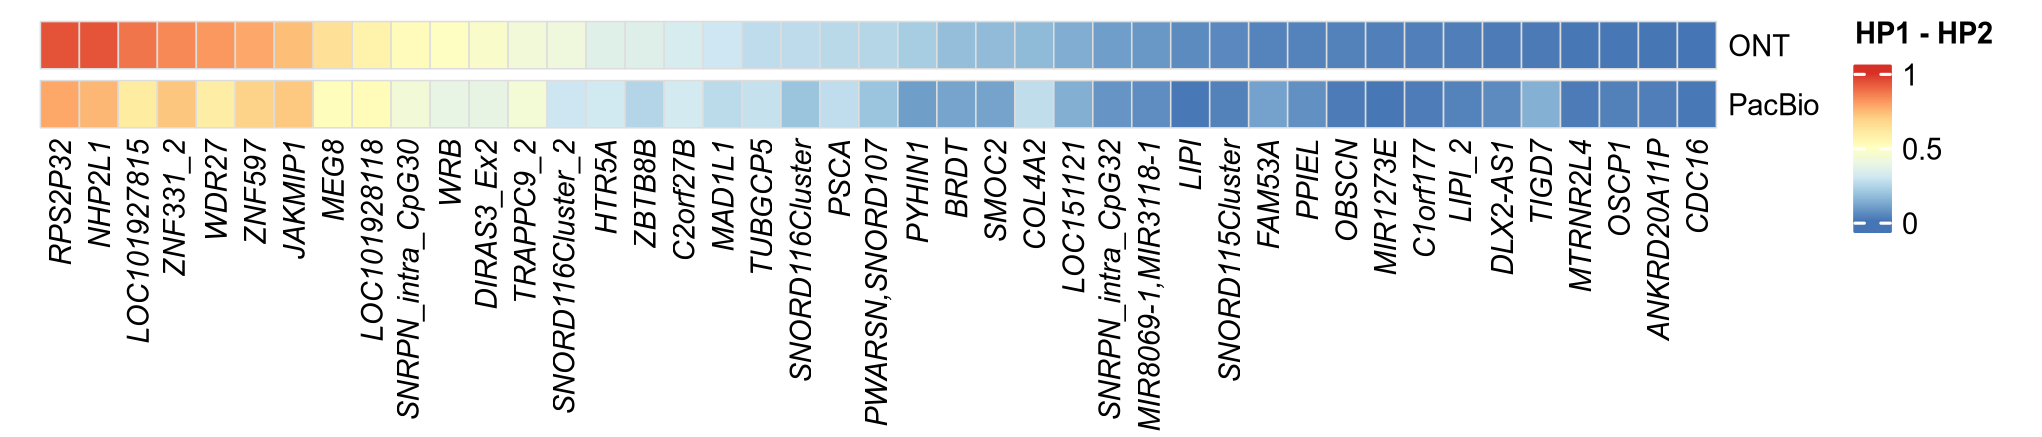

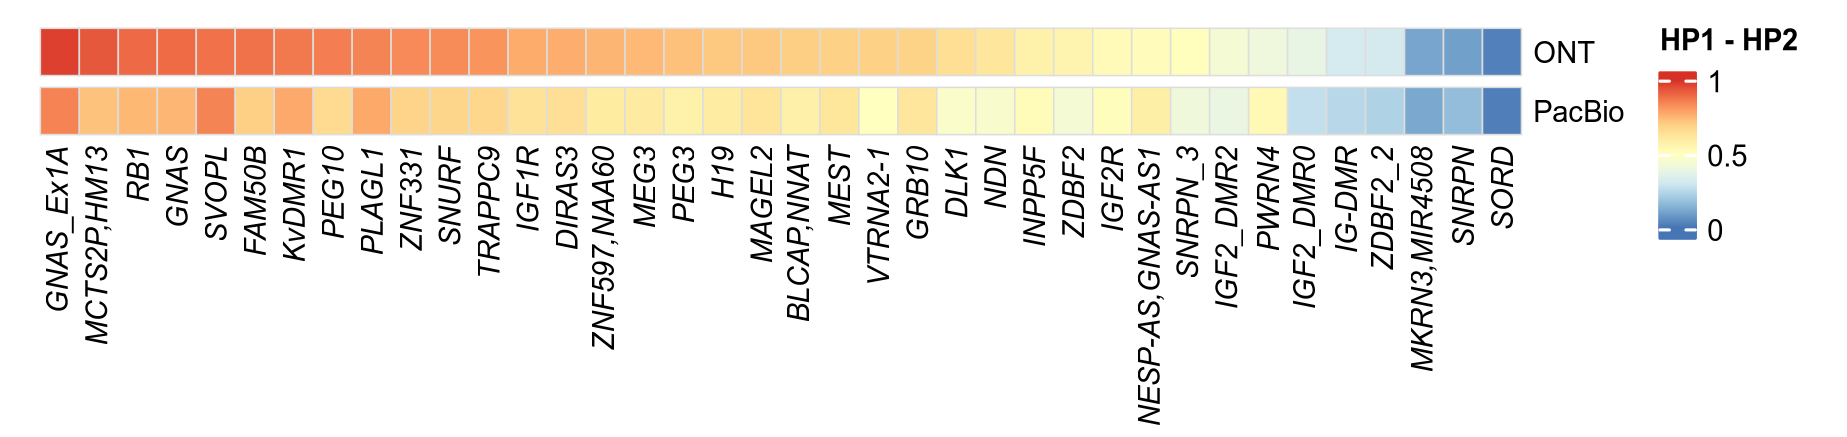

In [7]:
show('icr_heatmap_novel_nm.png', 'icr_heatmap_known_nm.png')

## f - methylation around transcription start sites, three platforms

wrote ./figures/notebook/tss_profile_nm.pdf/.png from 3 tracks x 80 bins of 50 bp  7.0 pt


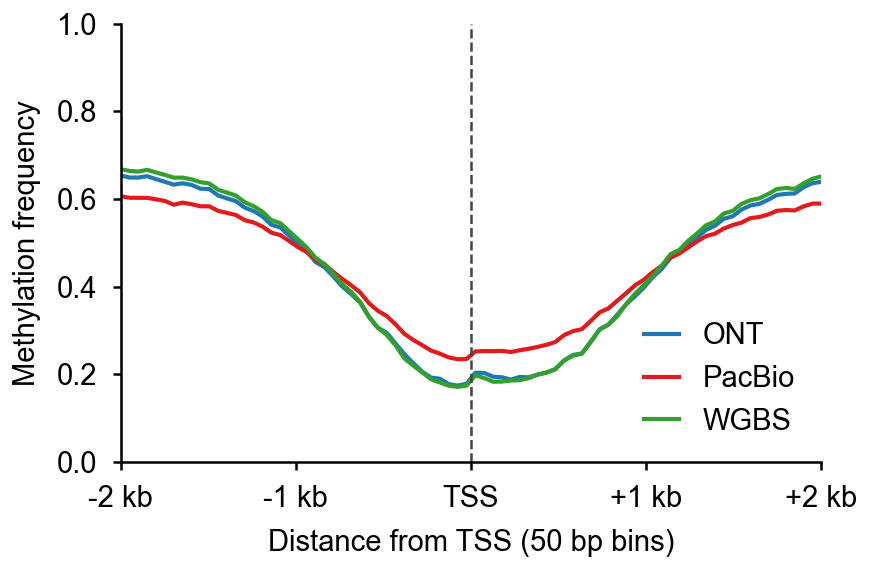

In [8]:
# scripts/paper/profile_nm.py, inlined. sys.argv is what the paper passes it.
import sys
sys.argv = ['profile_nm.py', f'{DATA}/ed_fig5/TSS_profile_3track_nozero_data.tsv', f'{OUT}/tss_profile_nm', 'TSS', '2000']
__file__ = "../scripts/paper/profile_nm.py"

"""Mean CpG methylation around a set of reference points (TSS or CTCF), three tracks, from the
deepTools plotProfile data table. 7 pt, 2.9 x 1.9 in: the first version at 3.5 x 1.7 was too flat to
read the dip at the reference point. Same parsing as suppfig2/42_plot_profile_12pt.py: a sample row
has a non-empty group column, the two header rows do not.

The bin width is printed on the x axis, because the two profiles do not share one. CTCF has fewer and
shorter regions than TSS, so a 50 bp bin there is a saw edge rather than a signal.

Usage: 13_profile_nm.py <profile_data.tsv> <out_stem> <centre> <flank_bp> [bin_bp]   (env: conda/envs/py39_v2)
"""
from __future__ import annotations

import os
import sys

import matplotlib
matplotlib.use("Agg")
import matplotlib.font_manager
import matplotlib.pyplot as plt
import numpy as np

PT = float(os.environ.get("PANEL_MIN_PT", 7))
COLORS = {"ONT": "#1f78b4", "PacBio": "#e31a1c", "WGBS": "#33a02c"}
FD = os.environ.get("LONGVERSE_FONT_DIR", "/project2/sli68423_1316/users/yang/software/fonts")
fam = "DejaVu Sans"
for t in ("arial.ttf", "arialbd.ttf"):
    if os.path.isfile(os.path.join(FD, t)):
        matplotlib.font_manager.fontManager.addfont(os.path.join(FD, t))
if os.path.isfile(os.path.join(FD, "arial.ttf")):
    fam = "Arial"
plt.rcParams.update({"font.family": fam, "font.size": PT, "axes.labelsize": PT, "xtick.labelsize": PT,
                     "ytick.labelsize": PT, "legend.fontsize": PT, "pdf.fonttype": 42, "ps.fonttype": 42,
                     "axes.spines.top": False, "axes.spines.right": False, "axes.linewidth": 0.6,
                     "xtick.major.width": 0.6, "ytick.major.width": 0.6, "xtick.major.size": 2, "ytick.major.size": 2})


def main() -> int:
    data, stem, centre, flank = sys.argv[1], sys.argv[2], sys.argv[3], int(sys.argv[4])
    binbp = int(sys.argv[5]) if len(sys.argv) > 5 else 50
    series = []
    for r in (l.rstrip("\n").split("\t") for l in open(data) if l.strip()):
        if len(r) < 3 or not r[1].strip():
            continue
        vals = np.array([float(v) if v not in ("", "nan") else np.nan for v in r[2:]])
        if not np.all(np.isnan(vals)):
            series.append((r[0].strip(), vals))
    if not series:
        raise SystemExit(f"no plottable rows in {data}")
    fig, ax = plt.subplots(figsize=(2.9, 1.9), constrained_layout=True)
    for name, y in series:
        ax.plot(np.linspace(-flank, flank, len(y)), y, lw=1.0, label=name, color=COLORS.get(name))
    ax.axvline(0, color="#444444", lw=0.6, ls="--")
    ax.set_xlim(-flank, flank); ax.set_ylim(0, 1)
    ax.set_xticks([-flank, -flank // 2, 0, flank // 2, flank])
    ax.set_xticklabels([f"-{flank // 1000} kb", f"-{flank // 2000} kb", centre, f"+{flank // 2000} kb", f"+{flank // 1000} kb"])
    ax.set_xlabel(f"Distance from {centre} ({binbp} bp bins)")
    ax.set_ylabel("Methylation frequency")
    ax.legend(frameon=False, loc="lower right", handlelength=1.2)
    fig.savefig(stem + ".pdf"); fig.savefig(stem + ".png", dpi=300)
    print(f"wrote {stem}.pdf/.png from {len(series)} tracks x {len(series[0][1])} bins of {binbp} bp  {PT} pt")
    return 0

main()
show("tss_profile_nm.png")

## g - CTCF, the same script with the other input

wrote ./figures/notebook/ctcf_profile_nm.pdf/.png from 3 tracks x 80 bins of 50 bp  7.0 pt


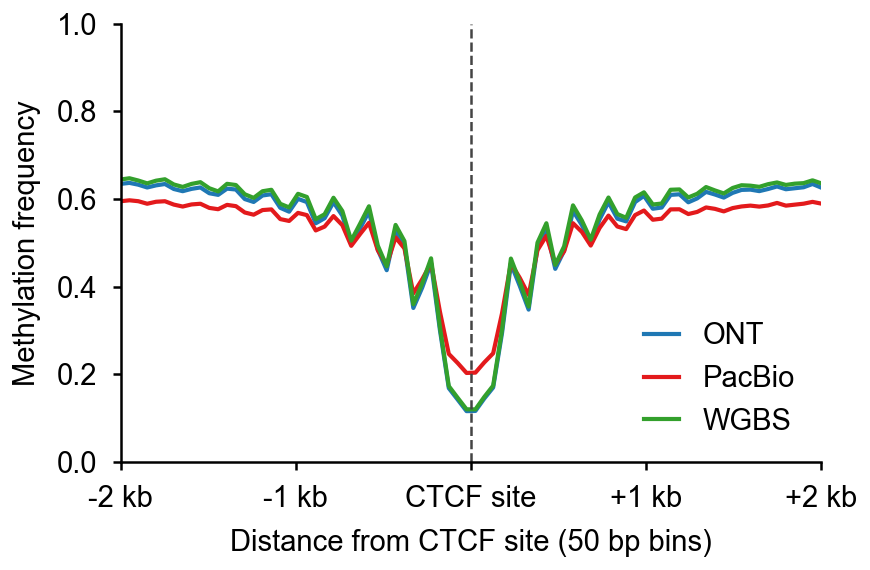

In [9]:
# scripts/paper/profile_nm.py, inlined. sys.argv is what the paper passes it.
import sys
sys.argv = ['profile_nm.py', f'{DATA}/ed_fig5/CTCF_profile_3track_nozero_data.tsv', f'{OUT}/ctcf_profile_nm', 'CTCF site', '2000']
__file__ = "../scripts/paper/profile_nm.py"

"""Mean CpG methylation around a set of reference points (TSS or CTCF), three tracks, from the
deepTools plotProfile data table. 7 pt, 2.9 x 1.9 in: the first version at 3.5 x 1.7 was too flat to
read the dip at the reference point. Same parsing as suppfig2/42_plot_profile_12pt.py: a sample row
has a non-empty group column, the two header rows do not.

The bin width is printed on the x axis, because the two profiles do not share one. CTCF has fewer and
shorter regions than TSS, so a 50 bp bin there is a saw edge rather than a signal.

Usage: 13_profile_nm.py <profile_data.tsv> <out_stem> <centre> <flank_bp> [bin_bp]   (env: conda/envs/py39_v2)
"""
from __future__ import annotations

import os
import sys

import matplotlib
matplotlib.use("Agg")
import matplotlib.font_manager
import matplotlib.pyplot as plt
import numpy as np

PT = float(os.environ.get("PANEL_MIN_PT", 7))
COLORS = {"ONT": "#1f78b4", "PacBio": "#e31a1c", "WGBS": "#33a02c"}
FD = os.environ.get("LONGVERSE_FONT_DIR", "/project2/sli68423_1316/users/yang/software/fonts")
fam = "DejaVu Sans"
for t in ("arial.ttf", "arialbd.ttf"):
    if os.path.isfile(os.path.join(FD, t)):
        matplotlib.font_manager.fontManager.addfont(os.path.join(FD, t))
if os.path.isfile(os.path.join(FD, "arial.ttf")):
    fam = "Arial"
plt.rcParams.update({"font.family": fam, "font.size": PT, "axes.labelsize": PT, "xtick.labelsize": PT,
                     "ytick.labelsize": PT, "legend.fontsize": PT, "pdf.fonttype": 42, "ps.fonttype": 42,
                     "axes.spines.top": False, "axes.spines.right": False, "axes.linewidth": 0.6,
                     "xtick.major.width": 0.6, "ytick.major.width": 0.6, "xtick.major.size": 2, "ytick.major.size": 2})


def main() -> int:
    data, stem, centre, flank = sys.argv[1], sys.argv[2], sys.argv[3], int(sys.argv[4])
    binbp = int(sys.argv[5]) if len(sys.argv) > 5 else 50
    series = []
    for r in (l.rstrip("\n").split("\t") for l in open(data) if l.strip()):
        if len(r) < 3 or not r[1].strip():
            continue
        vals = np.array([float(v) if v not in ("", "nan") else np.nan for v in r[2:]])
        if not np.all(np.isnan(vals)):
            series.append((r[0].strip(), vals))
    if not series:
        raise SystemExit(f"no plottable rows in {data}")
    fig, ax = plt.subplots(figsize=(2.9, 1.9), constrained_layout=True)
    for name, y in series:
        ax.plot(np.linspace(-flank, flank, len(y)), y, lw=1.0, label=name, color=COLORS.get(name))
    ax.axvline(0, color="#444444", lw=0.6, ls="--")
    ax.set_xlim(-flank, flank); ax.set_ylim(0, 1)
    ax.set_xticks([-flank, -flank // 2, 0, flank // 2, flank])
    ax.set_xticklabels([f"-{flank // 1000} kb", f"-{flank // 2000} kb", centre, f"+{flank // 2000} kb", f"+{flank // 1000} kb"])
    ax.set_xlabel(f"Distance from {centre} ({binbp} bp bins)")
    ax.set_ylabel("Methylation frequency")
    ax.legend(frameon=False, loc="lower right", handlelength=1.2)
    fig.savefig(stem + ".pdf"); fig.savefig(stem + ".png", dpi=300)
    print(f"wrote {stem}.pdf/.png from {len(series)} tracks x {len(series[0][1])} bins of {binbp} bp  {PT} pt")
    return 0

main()
show("ctcf_profile_nm.png")

## h - ONT against PacBio within eight genomic region classes

**Not the paper's drawing code**, for the same reason as Extended Data Fig. 4a-c: the paper's script loads RData objects up to 890 MB.

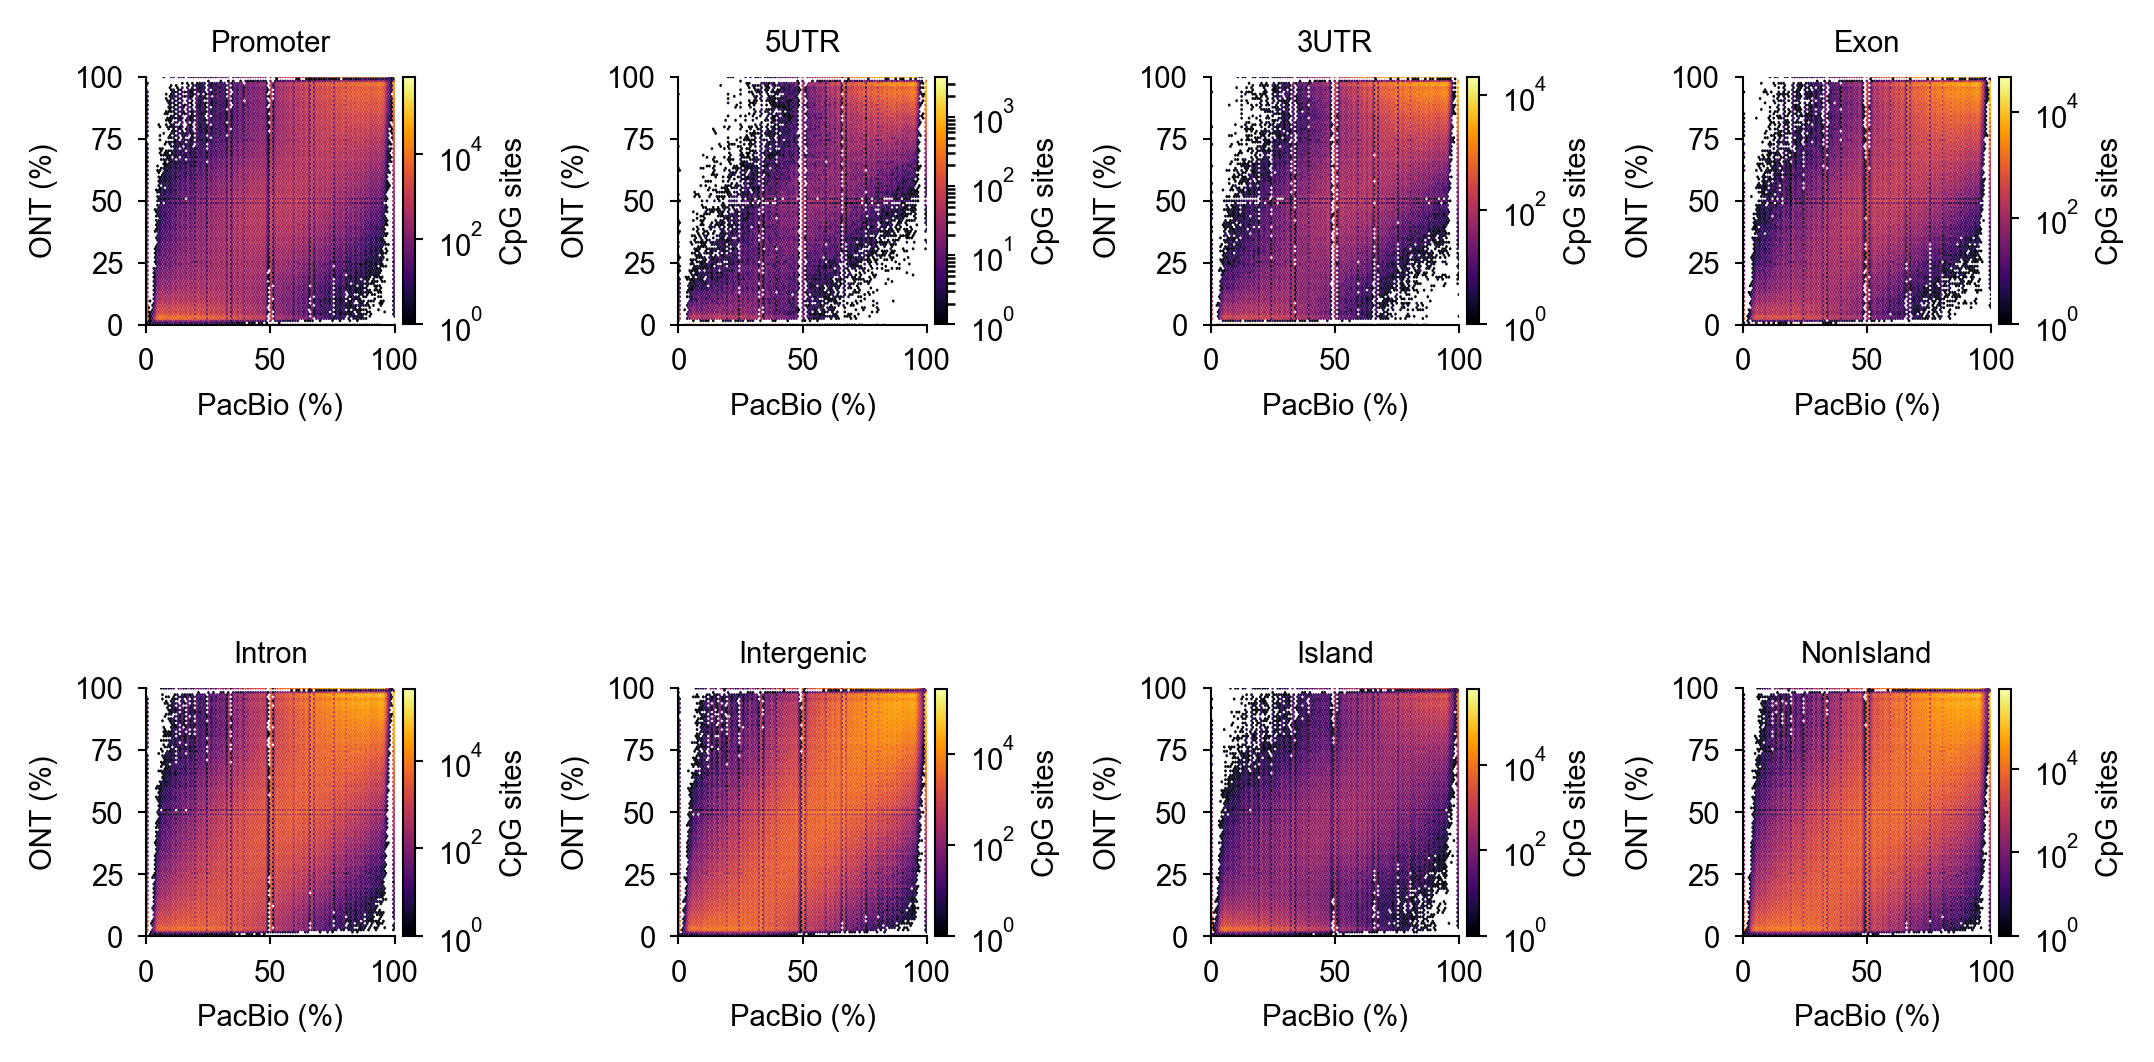

In [10]:
import panels as P
import matplotlib.pyplot as plt
P.style()

regions = ["Promoter", "5UTR", "3UTR", "Exon", "Intron", "Intergenic", "Island", "NonIsland"]
fig, axes = plt.subplots(2, 4, figsize=(7.2, 4.2))
for reg, ax in zip(regions, axes.ravel()):
    P.hexbin(f"ed5_f_{reg}", "PacBio (%)", "ONT (%)", ax=ax)
    ax.set_title(reg)
fig.tight_layout()
for ext in ("pdf", "png"):
    fig.savefig(OUT / f"ed5h_region_hexbins.{ext}", bbox_inches="tight")
plt.close(fig)
show("ed5h_region_hexbins.png")